In [1]:
import MDAnalysis as mda
from MDAnalysis.analysis.dssp import DSSP, translate
from ase.io import read, write
import os
import numpy as np
import mdtraj as md

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# try:
#     os.remove("ala15_dyn.xyz")
# except FileNotFoundError:
#     pass
# images = read("ala15_dyn.traj", ":")
# write("ala15_dyn.xyz", images) 

# u = mda.Universe("ala15.pdb","ala15_dyn.xyz")  
u = mda.Universe("ala15_dyn_obabel.pdb")

In [3]:
# traj = md.load("ala15_dyn.xyz", top="ala15.pdb")
traj = md.load("ala15_dyn_obabel.pdb")

In [5]:
from mdtraj import compute_dssp
ss_full = compute_dssp(traj, simplified=False)  # shape (n_frames, n_residues)

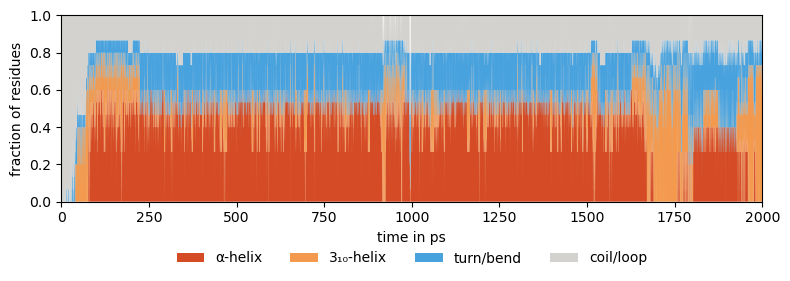

In [38]:
import numpy as np
import matplotlib.pyplot as plt

n_frames, n_res = ss_full.shape

# convert to plain strings for convenience
ss_full = ss_full.astype(str)

# time axis (frames → ps)
dt_ps = 0.05  # set to your real timestep
time = np.arange(n_frames) * dt_ps

# helper: fraction of residues in a given state set for one frame
def frac(state_set, frame_ss):
    return sum(s in state_set for s in frame_ss) / n_res

frac_alpha = np.zeros(n_frames)   # H
frac_310   = np.zeros(n_frames)   # G
frac_pi    = np.zeros(n_frames)   # I
frac_beta  = np.zeros(n_frames)   # E, B
frac_turn  = np.zeros(n_frames)   # T, S
frac_coil  = np.zeros(n_frames)   # loops / space

for i in range(n_frames):
    frame_ss = ss_full[i]

    frac_alpha[i] = frac({"H"}, frame_ss)
    frac_310[i]   = frac({"G"}, frame_ss)
    frac_pi[i]    = frac({"I"}, frame_ss)
    frac_beta[i]  = frac({"E", "B"}, frame_ss)
    frac_turn[i]  = frac({"T", "S"}, frame_ss)
    frac_coil[i]  = frac({" "}, frame_ss)   # DSSP loop/irregular

plt.figure(figsize=(8, 3))

colors = ['#d0370d', '#f28f3b', '#3498db', '#CFCDC9']

plt.stackplot(
    time,
    frac_alpha,
    frac_310,
    frac_turn,
    frac_coil,
    labels=[
        "α-helix",
        "3₁₀-helix",
        "turn/bend",
        "coil/loop"
    ],
    colors=colors,
    alpha=0.9,
)

plt.xlabel("time in ps")
plt.ylabel("fraction of residues")
plt.ylim(0, 1.0)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=4, frameon=False)

plt.xlim([0, 2000])
plt.tight_layout()
plt.savefig("alaning.png", dpi=500)
plt.show()